In [1]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import json
from pathlib import Path
import random
from PIL import Image
import os
import sys
import io
import numpy as np
import torch
from omegaconf import OmegaConf
from torchvision import transforms

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

src_path = '/mnt/DATA2/dorin/Image-Transform-Predict/src'
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from src.dataset import ImageTransformer
from src.dataset import TransformTokenizer
from src.dataset import DomainNetDataset
from src.dataset import NegativeImagePairDataset
from model import ImageTransformPredictor


# plt.rcParams.update({
#     'text.usetex': False,
#     'font.family': 'serif',
#     'font.serif': ['DejaVu Serif'],  # ← Ключевое исправление
#     'font.size': 14,
#     'axes.labelsize': 14,
#     'axes.titlesize': 16,
#     'xtick.labelsize': 12,
#     'ytick.labelsize': 12,
#     'legend.fontsize': 12,
#     'lines.linewidth': 1.5,
#     'lines.markersize': 8,
#     'grid.alpha': 0.3,
#     'figure.dpi': 300,
#     'font.weight': 'normal',
# })

%load_ext autoreload
%autoreload 2

In [2]:
src_path = '/mnt/DATA2/dorin/res.cv.science.dataset.generation/src'
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from pairwise_comparison_validation import RecallRobustnessEvaluator, plot_recall_robustness, FprEvaluator, plot_fpr_robustness
from categorization_visualization import plot_classification_histogram, DatasetSampler

### DomainNet Bench

In [3]:
from recall_fpr_bench import DomainRecallEvaluator, DomainFprEvaluator
from src.dataset import SimpleDomainNetDataset

In [4]:
tokenizer = TransformTokenizer()
transformer = ImageTransformer()

In [6]:
path = "/mnt/DATA2/dorin/Image-Transform-Predict/data"
data =  SimpleDomainNetDataset(path, split="val")

In [7]:
data.domain_distribution

{'clipart': 4812,
 'infograph': 5160,
 'painting': 7226,
 'quickdraw': 17250,
 'real': 17294,
 'sketch': 6912}

In [9]:
image, image_class = data[5000]
# image

In [10]:
preprocess = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

config = OmegaConf.load('/mnt/DATA2/dorin/Image-Transform-Predict/configs/train_config_vit.yaml')
model = ImageTransformPredictor(config.model)

checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_vit/checkpoint_epoch_100.pth'
# checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_vit_tune_full/checkpoint_epoch_35.pth'

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.to('cpu')
model.eval()
print('ready')

def sim_fn_itp_vit(img1, img2):
    image_tensor_1 = preprocess(img1).unsqueeze(0)
    image_tensor_2 = preprocess(img2).unsqueeze(0)

    generated = model.generate(image_tensor_1, image_tensor_2, max_new_tokens=10, do_sample=False)
    if generated[0][1] == 2: # выдало пустую последовательность
        similarity_score = 0.
    else:
        similarity_score = 1.
    return similarity_score

ready


In [ ]:
preprocess = transforms.Compose([
            transforms.Resize((300, 300)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

config = OmegaConf.load('/mnt/DATA2/dorin/Image-Transform-Predict/configs/train_config_011.yaml')
model = ImageTransformPredictor(config.model)

checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_011/checkpoint_epoch_50.pth'
# checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_011_tune_full/checkpoint_epoch_15.pth'

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.to('cpu')
model.eval()
print('ready')

# model.load_state_dict(torch.load('/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_011/model_weights.pth'))
# model.to('cpu')
# model.eval()
# print('ready')

def sim_fn_itp_effnet(img1, img2):
    image_tensor_1 = preprocess(img1).unsqueeze(0)
    image_tensor_2 = preprocess(img2).unsqueeze(0)

    generated = model.generate(image_tensor_1, image_tensor_2, max_new_tokens=10, do_sample=False)
    if generated[0][1] == 2: # выдало пустую последовательность
        similarity_score = 0.
    else:
        similarity_score = 1.
    return similarity_score

In [ ]:
evaluator = DomainRecallEvaluator(
    data_dir="/mnt/DATA2/dorin/Image-Transform-Predict/data",
    sim_fn=sim_fn_itp_vit,
    preprocess=None, # нужен если не вшит в sim_fn
    seed=2025
)

results = evaluator.evaluate(n_samples=1000, threshold=0.5, model_name = "ours (ViT-B/16)", output_path = "recall_domainnet.json")

# results = evaluator.evaluate(n_samples=1000, threshold=0.5, model_name = "ours (EfficientNet-B3) before sft", output_path = "recall_negative_dataset.json")

Domains:   0%|          | 0/6 [00:00<?, ?it/s]

### Negative Bench

#### Analysis of the test sample

In [22]:
tokenizer = TransformTokenizer()
transformer = ImageTransformer()
batch_names = [
    "dataset_0", "dataset_1", "dataset_5", "dataset_9",
    "dataset_2", "dataset_18", "dataset_27", "dataset_36",
    "dataset_45", "dataset_270", "dataset_281", "dataset_150",
    "dataset_180"
]

negative_data = NegativeImagePairDataset(
        root_dir = "/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets",
        batch_names = batch_names,
        transformer = transformer,
        tokenizer = tokenizer,
        split = "val",
        val_size = 0.1,
        random_seed = 42,
        max_seq_len = 15,
        augmentation_p = 0.3
)

In [23]:
len(negative_data._pairs_and_meta)

69174

In [2]:
category_to_pairs = {}
dataset_root = Path("/mnt/DATA2/dorin/res.cv.science.dataset.generation")

In [42]:
def load_pairs(json_path: str) -> None:
    with open(json_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)

    for entry in metadata:
        c1 = entry.get("image_1_class")
        c2 = entry.get("image_2_class")
        if not (c1 and c2 and c1 == c2):
            continue  # skip cross-domain or missing classes

        p1 = dataset_root / entry["batch_name"] / "dataset" / entry["image_1"]
        p2 = dataset_root / entry["batch_name"] / "dataset" / entry["image_2"]
        category_to_pairs.setdefault(c1, []).append((p1, p2))

In [43]:
load_pairs("/mnt/DATA2/dorin/Image-Transform-Predict/negative_test_dataset_meta.json")

In [49]:
for cat in category_to_pairs.keys():
    print(cat, len(category_to_pairs[cat]))

text 5768
microscopy 23193
monotone 2670
diagram 2938
medical 3128
hand_drawn 215
other 6681
photo 400
face 384


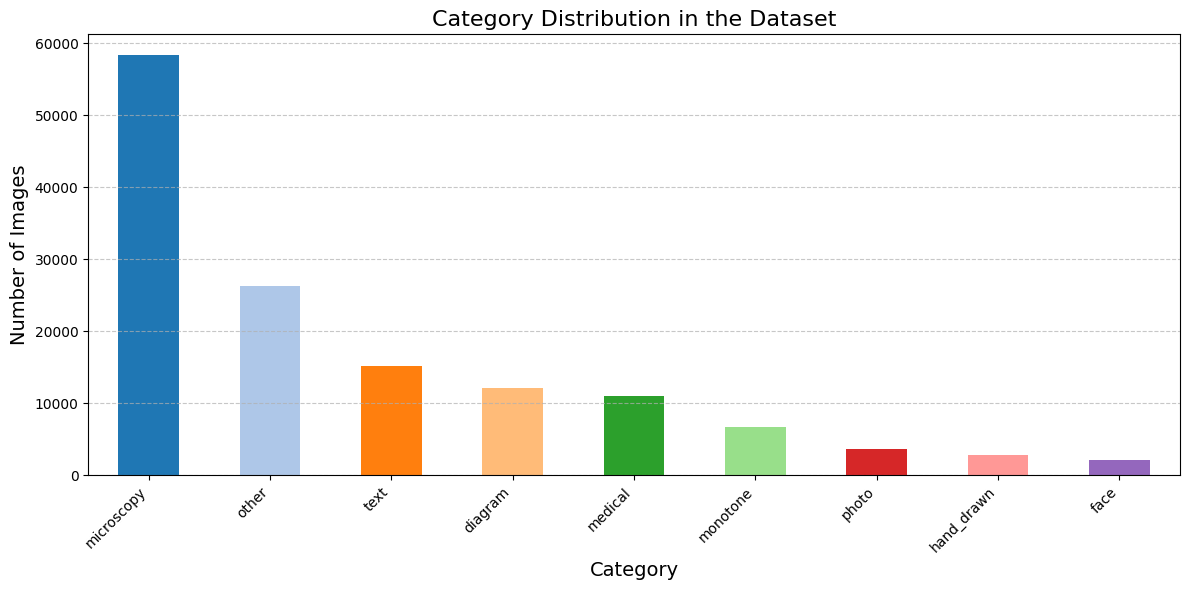

In [7]:
plot_classification_histogram("/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/negative_test_dataset_meta.json")

In [10]:
sampler = DatasetSampler("/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets", "/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/negative_test_dataset_meta.json")

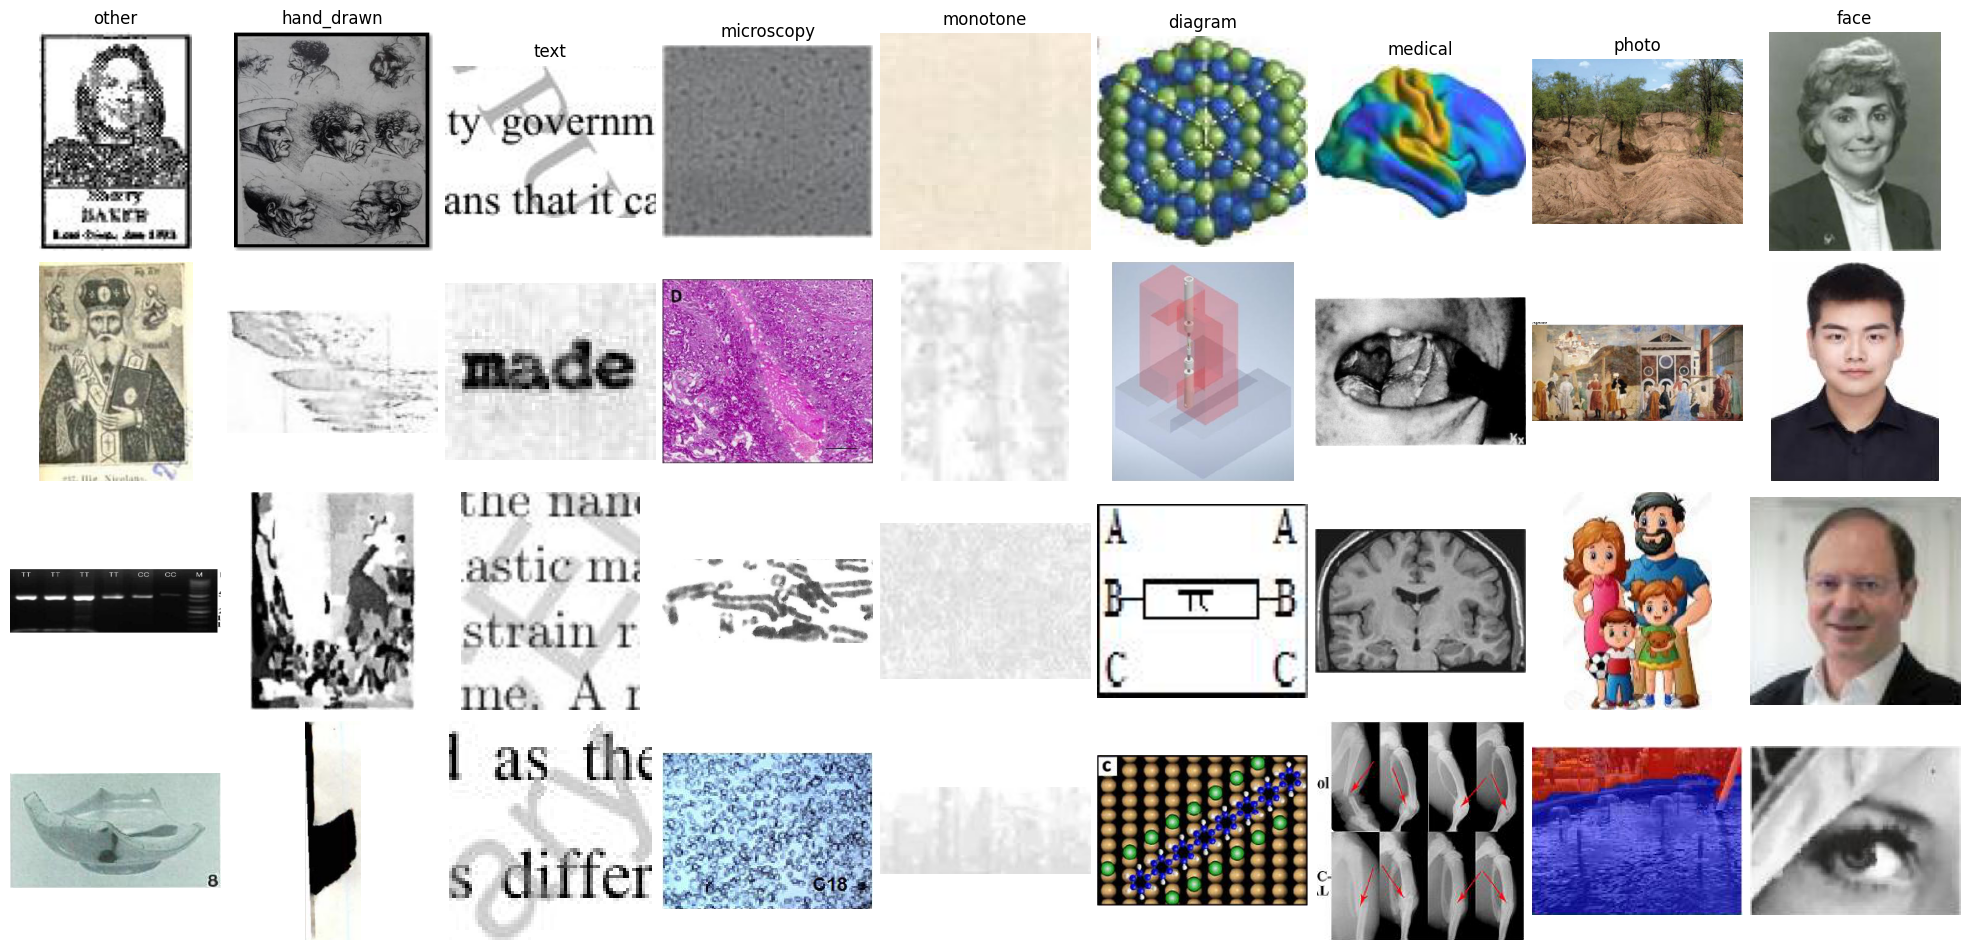

In [11]:
sampler.sample_and_display()

#### Evaluation of sequence prediction models (ViT based, EfficientNet based)

In [6]:
preprocess = transforms.Compose([
            transforms.Resize((300, 300)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

config = OmegaConf.load('/mnt/DATA2/dorin/Image-Transform-Predict/configs/train_config_011.yaml')
model = ImageTransformPredictor(config.model)

checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_011/checkpoint_epoch_50.pth'
# checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_011_tune_full/checkpoint_epoch_15.pth'

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.to('cpu')
model.eval()
print('ready')

# model.load_state_dict(torch.load('/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_011/model_weights.pth'))
# model.to('cpu')
# model.eval()
# print('ready')

def sim_fn_itp_effnet(img1, img2):
    image_tensor_1 = preprocess(img1).unsqueeze(0)
    image_tensor_2 = preprocess(img2).unsqueeze(0)

    generated = model.generate(image_tensor_1, image_tensor_2, max_new_tokens=10, do_sample=False)
    if generated[0][1] == 2: # выдало пустую последовательность
        similarity_score = 0.
    else:
        similarity_score = 1.
    return similarity_score

Loaded pretrained weights for efficientnet-b3
ready


In [3]:
preprocess = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

config = OmegaConf.load('/mnt/DATA2/dorin/Image-Transform-Predict/configs/train_config_vit.yaml')
model = ImageTransformPredictor(config.model)

checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_vit/checkpoint_epoch_100.pth'
# checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_vit_tune_full/checkpoint_epoch_35.pth'

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.to('cpu')
model.eval()
print('ready')

def sim_fn_itp_vit(img1, img2):
    image_tensor_1 = preprocess(img1).unsqueeze(0)
    image_tensor_2 = preprocess(img2).unsqueeze(0)

    generated = model.generate(image_tensor_1, image_tensor_2, max_new_tokens=10, do_sample=False)
    if generated[0][1] == 2: # выдало пустую последовательность
        similarity_score = 0.
    else:
        similarity_score = 1.
    return similarity_score

ready


In [7]:
evaluator = RecallRobustnessEvaluator(
    dataset_root="/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets",
    json_path="/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/negative_test_dataset_meta.json",
    sim_fn=sim_fn_itp_effnet,
    preprocess=None, # нужен если не вшит в sim_fn
    seed=2025
)

results = evaluator.evaluate(n_samples=1000, threshold=0.5, model_name = "ours (EfficientNet-B3) before sft", output_path = "recall_negative_dataset.json")

 11%|█         | 1/9 [19:31<2:36:08, 1171.05s/it]

Category: diagram | N = 1000
  color_jitter    --> recall = 0.995
  crop            --> recall = 0.972
  crop_colorjitter_flipv --> recall = 0.897
  flip_vertical   --> recall = 1.000
  fliph_rot270_grayscale --> recall = 1.000
  grayscale       --> recall = 1.000
  jpeg_artefacts  --> recall = 0.997
  rotate_180      --> recall = 1.000
  rotate_90       --> recall = 1.000


 22%|██▏       | 2/9 [38:46<2:15:32, 1161.77s/it]

Category: face | N = 1000
  color_jitter    --> recall = 0.999
  crop            --> recall = 0.975
  crop_colorjitter_flipv --> recall = 0.925
  flip_vertical   --> recall = 1.000
  fliph_rot270_grayscale --> recall = 1.000
  grayscale       --> recall = 1.000
  jpeg_artefacts  --> recall = 0.996
  rotate_180      --> recall = 1.000
  rotate_90       --> recall = 1.000


 33%|███▎      | 3/9 [58:20<1:56:44, 1167.38s/it]

...

Category: other | N = 1000
  color_jitter    --> recall = 0.994
  crop            --> recall = 0.971
  crop_colorjitter_flipv --> recall = 0.894
  flip_vertical   --> recall = 1.000
  fliph_rot270_grayscale --> recall = 1.000
  grayscale       --> recall = 1.000
  jpeg_artefacts  --> recall = 0.999
  rotate_180      --> recall = 1.000
  rotate_90       --> recall = 1.000


 89%|████████▉ | 8/9 [2:33:50<19:19, 1159.59s/it]

Category: photo | N = 1000
  color_jitter    --> recall = 1.000
  crop            --> recall = 0.983
  crop_colorjitter_flipv --> recall = 0.893
  flip_vertical   --> recall = 1.000
  fliph_rot270_grayscale --> recall = 1.000
  grayscale       --> recall = 1.000
  jpeg_artefacts  --> recall = 0.999
  rotate_180      --> recall = 1.000
  rotate_90       --> recall = 1.000


100%|██████████| 9/9 [2:52:50<00:00, 1152.24s/it]

Category: text | N = 1000
  color_jitter    --> recall = 1.000
  crop            --> recall = 0.988
  crop_colorjitter_flipv --> recall = 0.961
  flip_vertical   --> recall = 1.000
  fliph_rot270_grayscale --> recall = 1.000
  grayscale       --> recall = 1.000
  jpeg_artefacts  --> recall = 0.998
  rotate_180      --> recall = 1.000
  rotate_90       --> recall = 1.000

Saved results for 'ours (EfficientNet-B3) before sft' to 'recall_negative_dataset.json'


In [5]:
evaluator = RecallRobustnessEvaluator(
    dataset_root="/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets",
    json_path="/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/negative_test_dataset_meta.json",
    sim_fn=sim_fn_itp_vit,
    preprocess=None, # нужен если не вшит в sim_fn
    seed=2025
)

results = evaluator.evaluate(n_samples=1000, threshold=0.5, model_name = "ours (ViT-B/16) before sft", output_path = "recall_negative_dataset.json")

 11%|█         | 1/9 [30:09<4:01:14, 1809.31s/it]

Category: diagram | N = 1000
  color_jitter    --> recall = 0.995
  crop            --> recall = 0.966
  crop_colorjitter_flipv --> recall = 0.883
  flip_vertical   --> recall = 1.000
  fliph_rot270_grayscale --> recall = 1.000
  grayscale       --> recall = 1.000
  jpeg_artefacts  --> recall = 0.999
  rotate_180      --> recall = 1.000
  rotate_90       --> recall = 1.000


 22%|██▏       | 2/9 [59:50<3:29:09, 1792.85s/it]

Category: face | N = 1000
  color_jitter    --> recall = 1.000
  crop            --> recall = 0.952
  crop_colorjitter_flipv --> recall = 0.897
  flip_vertical   --> recall = 1.000
  fliph_rot270_grayscale --> recall = 1.000
  grayscale       --> recall = 1.000
  jpeg_artefacts  --> recall = 1.000
  rotate_180      --> recall = 1.000
  rotate_90       --> recall = 1.000


 33%|███▎      | 3/9 [1:31:10<3:03:15, 1832.50s/it]

...

Category: other | N = 1000
  color_jitter    --> recall = 0.998
  crop            --> recall = 0.956
  crop_colorjitter_flipv --> recall = 0.897
  flip_vertical   --> recall = 1.000
  fliph_rot270_grayscale --> recall = 1.000
  grayscale       --> recall = 1.000
  jpeg_artefacts  --> recall = 1.000
  rotate_180      --> recall = 1.000
  rotate_90       --> recall = 1.000


 89%|████████▉ | 8/9 [4:08:08<31:14, 1874.42s/it]  

Category: photo | N = 1000
  color_jitter    --> recall = 1.000
  crop            --> recall = 0.967
  crop_colorjitter_flipv --> recall = 0.904
  flip_vertical   --> recall = 1.000
  fliph_rot270_grayscale --> recall = 1.000
  grayscale       --> recall = 1.000
  jpeg_artefacts  --> recall = 1.000
  rotate_180      --> recall = 1.000
  rotate_90       --> recall = 1.000


100%|██████████| 9/9 [4:39:58<00:00, 1866.46s/it]

Category: text | N = 1000
  color_jitter    --> recall = 0.970
  crop            --> recall = 0.983
  crop_colorjitter_flipv --> recall = 0.901
  flip_vertical   --> recall = 1.000
  fliph_rot270_grayscale --> recall = 1.000
  grayscale       --> recall = 1.000
  jpeg_artefacts  --> recall = 1.000
  rotate_180      --> recall = 1.000
  rotate_90       --> recall = 1.000

Saved results for 'ours (ViT-B/16) before sft' to 'recall_negative_dataset.json'


In [8]:
evaluator = FprEvaluator(
    dataset_root="/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets",
    json_path="/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/negative_test_dataset_meta.json",
    sim_fn=sim_fn_itp_effnet,
    preprocess=None, # нужен если не вшит в sim_fn
    seed=2025
)

results = evaluator.evaluate(n_samples=1000, threshold=0.5, model_name = "ours (EfficientNet-B3) before sft", output_path = "fpr_negative_dataset.json")

Domains:  11%|█         | 1/9 [03:10<25:24, 190.57s/it]

Domain: diagram | N = 1000 | FPR = 68/1000 = 0.068


Domains:  22%|██▏       | 2/9 [04:13<13:27, 115.31s/it]

Domain: face | N = 384 | FPR = 69/384 = 0.180


Domains:  33%|███▎      | 3/9 [04:58<08:20, 83.47s/it] 

...

Domain: other | N = 1000 | FPR = 58/1000 = 0.058


Domains:  89%|████████▉ | 8/9 [19:23<02:32, 152.40s/it]

Domain: photo | N = 400 | FPR = 27/400 = 0.068


Domains: 100%|██████████| 9/9 [22:16<00:00, 148.52s/it]

Domain: text | N = 1000 | FPR = 336/1000 = 0.336

Saved domain-wise FPR for 'ours (EfficientNet-B3) before sft' to 'fpr_negative_dataset.json'


In [9]:
evaluator = FprEvaluator(
    dataset_root="/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets",
    json_path="/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/negative_test_dataset_meta.json",
    sim_fn=sim_fn_itp_vit,
    preprocess=None, # нужен если не вшит в sim_fn
    seed=2025
)

results = evaluator.evaluate(n_samples=1000, threshold=0.5, model_name = "ours (ViT-B/16) before sft", output_path = "fpr_negative_dataset.json")

Domains:  11%|█         | 1/9 [03:25<27:26, 205.81s/it]

Domain: diagram | N = 1000 | FPR = 68/1000 = 0.068


Domains:  22%|██▏       | 2/9 [04:42<15:09, 129.90s/it]

Domain: face | N = 384 | FPR = 69/384 = 0.180


Domains:  33%|███▎      | 3/9 [05:37<09:32, 95.50s/it] 

...

Domain: other | N = 1000 | FPR = 58/1000 = 0.058


Domains:  89%|████████▉ | 8/9 [22:27<03:04, 184.27s/it]

Domain: photo | N = 400 | FPR = 27/400 = 0.068


Domains: 100%|██████████| 9/9 [27:13<00:00, 181.51s/it]

Domain: text | N = 1000 | FPR = 336/1000 = 0.336

Saved domain-wise FPR for 'ours (ViT-B/16) before sft' to 'fpr_negative_dataset.json'


#### Comparison with Qwen3-VL-4B-Instruct in the task of predicting the transformation sequence

In [3]:
# !pip install transformers==4.57.0
# !pip install qwen_vl_utils

In [4]:
import torch

from transformers import AutoTokenizer, AutoProcessor
from transformers import Qwen3VLForConditionalGeneration
from qwen_vl_utils import process_vision_info
from PIL import Image

if not hasattr(torch.compiler, "is_compiling"):
    torch.compiler.is_compiling = lambda: False

In [5]:
model = Qwen3VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen3-VL-4B-Instruct",
)

# Store processor for preprocessing
processor = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-4B-Instruct")

model.to("cuda")
print("ready")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

ready


In [7]:
prompt_class_prediction = """You are an expert in image forensics. Determine whether Image B is a plagiarized version of Image A, meaning it was obtained by applying only the following allowed transformations to Image A:  
- Geometric: rotate_90, rotate_180, rotate_270, horizontal_flip, vertical_flip  
- Photometric: grayscale, color_jitter  
- Structural: crop (central square)  
- Noise/compression: noise_adding, jpeg_artefacts  

If Image B can be produced from Image A using any combination of these operations (in any order, without repetition), output 1.  
If Image B involves any other transformation (e.g., blur, resize, perspective warp, object removal, or unrelated content), output 0.

Output only a single digit: 1 or 0. Do not add any other text, explanation, or punctuation."""

['jpeg_artefacts', 'crop']


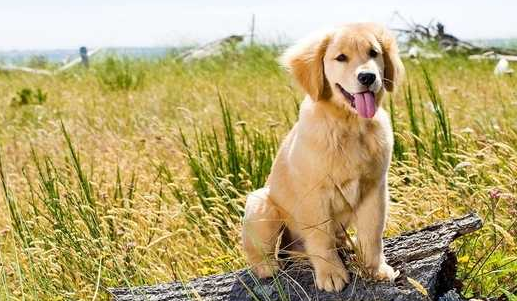

In [17]:
image = Image.open('../assets/dog.jpg')
image_car = Image.open('/mnt/DATA2/dorin/imgs/car/image1.jpg')
transformed_image, sequence = transformer.transform_by_length(image, 2)

print(sequence)
transformed_image.show()

In [18]:
import re
import torch

def sim_fn_qwen(img1, img2):
    # Ensure model is in eval mode to disable dropout, etc.
    was_training = model.training
    model.eval()
    
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": img1},
            {"type": "image", "image": img2},
            {"type": "text", "text": prompt_class_prediction},
        ],
    }]

    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():  # critical: disable gradient tracking
        generated_ids = model.generate(**inputs, max_new_tokens=128)

    # Extract only the needed part
    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs["input_ids"], generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0].strip()

    # Clean up GPU tensors immediately
    del inputs, generated_ids, generated_ids_trimmed
    if torch.cuda.is_available():
        torch.cuda.empty_cache()  # optional, but safe for long runs

    match = re.fullmatch(r'[01]', output_text)
    if match:
        return float(match.group(0))
    else:
        raise ValueError(f"Unexpected model output: '{output_text}'. Expected '0' or '1'.")

In [19]:
sim_fn_qwen(image, transformed_image)

1.0

In [20]:
evaluator = RecallRobustnessEvaluator(
    dataset_root="/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets",
    json_path="/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/negative_test_dataset_meta.json",
    sim_fn=sim_fn_qwen,
    preprocess=None, # нужен если не вшит в sim_fn
    seed=2025
)

results = evaluator.evaluate(n_samples=1000, threshold=0.5, model_name = "Qwen3-VL-4B", output_path = "recall_negative_dataset.json")

  0%|          | 0/9 [00:00<?, ?it/s]

[Score error] /mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets/dataset_5/dataset/009027696_2.png, rotate_90: CUDA out of memory. Tried to allocate 524.00 MiB. GPU 0 has a total capacity of 23.69 GiB of which 297.44 MiB is free. Process 1085505 has 23.39 GiB memory in use. Of the allocated memory 22.33 GiB is allocated by PyTorch, and 777.25 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
[Score error] /mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets/dataset_5/dataset/009027696_2.png, rotate_180: CUDA out of memory. Tried to allocate 524.00 MiB. GPU 0 has a total capacity of 23.69 GiB of which 297.44 MiB is free. Process 1085505 has 23.39 GiB memory in use. Of the allocated memory 22.36 GiB is allocated by PyTorch, and 744.90 MiB is re

 11%|█         | 1/9 [1:04:46<8:38:14, 3886.79s/it]

Category: diagram | N = 1000
  color_jitter    --> recall = 0.734
  crop            --> recall = 0.891
  crop_colorjitter_flipv --> recall = 0.493
  flip_vertical   --> recall = 0.697
  fliph_rot270_grayscale --> recall = 0.546
  grayscale       --> recall = 0.925
  jpeg_artefacts  --> recall = 0.960
  rotate_180      --> recall = 0.764
  rotate_90       --> recall = 0.772


 22%|██▏       | 2/9 [1:52:49<6:24:31, 3295.98s/it]

...

Category: other | N = 1000
  color_jitter    --> recall = 0.773
  crop            --> recall = 0.957
  crop_colorjitter_flipv --> recall = 0.497
  flip_vertical   --> recall = 0.737
  fliph_rot270_grayscale --> recall = 0.733
  grayscale       --> recall = 0.984
  jpeg_artefacts  --> recall = 0.982
  rotate_180      --> recall = 0.746
  rotate_90       --> recall = 0.822
[Score error] /mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets/dataset_0/dataset/000000425_2.png, rotate_90: CUDA out of memory. Tried to allocate 524.00 MiB. GPU 0 has a total capacity of 23.69 GiB of which 297.44 MiB is free. Process 1085505 has 23.39 GiB memory in use. Of the allocated memory 22.33 GiB is allocated by PyTorch, and 777.25 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-v

 89%|████████▉ | 8/9 [8:30:29<1:13:41, 4421.05s/it]

Category: photo | N = 1000
  color_jitter    --> recall = 0.746
  crop            --> recall = 0.928
  crop_colorjitter_flipv --> recall = 0.367
  flip_vertical   --> recall = 0.577
  fliph_rot270_grayscale --> recall = 0.671
  grayscale       --> recall = 0.966
  jpeg_artefacts  --> recall = 0.953
  rotate_180      --> recall = 0.523
  rotate_90       --> recall = 0.759


100%|██████████| 9/9 [9:48:22<00:00, 3922.53s/it]  

Category: text | N = 1000
  color_jitter    --> recall = 0.986
  crop            --> recall = 0.970
  crop_colorjitter_flipv --> recall = 0.659
  flip_vertical   --> recall = 0.744
  fliph_rot270_grayscale --> recall = 0.689
  grayscale       --> recall = 0.994
  jpeg_artefacts  --> recall = 0.995
  rotate_180      --> recall = 0.763
  rotate_90       --> recall = 0.870

Saved results for 'Qwen3-VL-4B' to 'recall_negative_dataset.json'


In [21]:
evaluator = FprEvaluator(
    dataset_root="/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets",
    json_path="/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/negative_test_dataset_meta.json",
    sim_fn=sim_fn_qwen,
    preprocess=None, # нужен если не вшит в sim_fn
    seed=2025
)

results = evaluator.evaluate(n_samples=1000, threshold=0.5, model_name = "Qwen3-VL-4B", output_path = "fpr_negative_dataset.json")

Domains:  11%|█         | 1/9 [32:36<4:20:55, 1956.96s/it]

Domain: diagram | N = 1000 | FPR = 61/1000 = 0.061


Domains:  22%|██▏       | 2/9 [42:35<2:15:03, 1157.62s/it]

Domain: face | N = 384 | FPR = 40/384 = 0.104


Domains:  33%|███▎      | 3/9 [52:30<1:30:05, 900.95s/it] 

...

Domains:  89%|████████▉ | 8/9 [2:45:02<19:14, 1154.98s/it]

Domain: photo | N = 400 | FPR = 29/400 = 0.072


Domains: 100%|██████████| 9/9 [2:55:57<00:00, 1173.11s/it]

Domain: text | N = 1000 | FPR = 214/1000 = 0.214



Saved domain-wise FPR for 'Qwen3-VL-4B' to 'fpr_negative_dataset.json'
